In [18]:
from PIL import Image

normal_eq = Image.open("lr_eq.png")

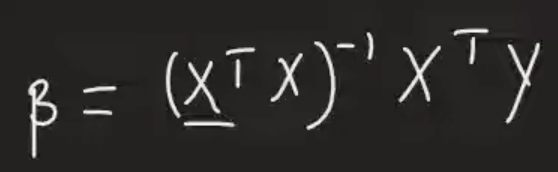

In [19]:
normal_eq

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [21]:
class LR:

    def __init__(self):
        self.slope = None
        self.intercept = None

    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1)
        #To multiply 1's to b knot

        #betas is b1,b2,etc.
        betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
        self.intercept = betas[0]
        self.slope = betas[1:]

    def predict(self,X_test):
        y_pred = np.dot(X_test,self.slope) + self.intercept
        return y_pred
        #y = mx + b

In [22]:
df = pd.read_csv('../datasets/house-train.csv',usecols=['GarageArea','LotArea','SalePrice'])

In [23]:
df = df.dropna()

In [24]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [25]:
X

,LotArea,GarageArea
0,8450,548
1,9600,460
2,11250,608
3,9550,642
4,14260,836
...,...,...
1455,7917,460
1456,13175,500
1457,9042,252
1458,9717,240


In [26]:
y

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [28]:
lr = LR()

In [29]:
lr.fit(X_train,y_train)

In [31]:
y_pred = lr.predict(X_test)

In [32]:
lr.slope

array([  1.14554792, 217.98411404])

In [33]:
lr.intercept

np.float64(65375.884730405814)

In [34]:
from sklearn.metrics import r2_score

In [35]:
r2_score(y_test,y_pred)

0.4050415891009401